Fill missing HomePlanet based on group majority ID
Extract Deck from Cabin (the first letter before '/')
Fill missing HomePlanet with 'Mars'
Fill missing Deck with random choice among D, E, F

Các giá trị còn lại điền median 
và điền giá trị xuất hiện nhiều nhất 
Bỏ feature Name à Cabin 

In [1]:
import pandas as pd 

train = pd.read_csv('space/raw/train.csv')

In [ ]:
train['Transported'] = train['Transported'].astype('int64')

numerical = train.select_dtypes(include=['int64', 'float64']).columns
categorical = train.select_dtypes(include='object').columns

def missing(df, feature):
    total = df[feature].isnull().sum()
    percent = (total / len(df)) * 100
    stats = pd.DataFrame({'total': total, 'percentage': percent})
    stats = stats[stats['total'] > 0]
    return stats 

num = missing(train, numerical)
print('for numerical')
print(num)

cat = missing(train, categorical)
print('\n for categorical: ')
print(cat)

for numerical
              total  percentage
Age             179    2.059128
RoomService     181    2.082135
FoodCourt       183    2.105142
ShoppingMall    208    2.392730
Spa             183    2.105142
VRDeck          188    2.162660

 for categorical: 
             total  percentage
HomePlanet     201    2.312205
CryoSleep      217    2.496261
Cabin          199    2.289198
Destination    182    2.093639
VIP            203    2.335212
Name           200    2.300702
['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']
Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')
int32


In [3]:
# giả sử cột ID là 'PassengerId' và cột cần điền là 'HomePlanet'

# tạo cột prefix từ PassengerId (4 số đầu trước dấu "_")
train['GroupId'] = train['PassengerId'].str.split('_').str[0]

# với mỗi GroupId, lấy HomePlanet phổ biến nhất (mode)
group_homeplanet = train.groupby('GroupId')['HomePlanet'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else None)

# map lại vào bảng train
train['HomePlanet'] = train.apply(
    lambda row: group_homeplanet[row['GroupId']] if pd.isnull(row['HomePlanet']) else row['HomePlanet'],
    axis=1
)

In [4]:
train['CabinDeck'] = train['Cabin'].str[0]

# thống kê tần suất CabinDeck theo HomePlanet
deck_stats = train.groupby('HomePlanet')['CabinDeck'].value_counts()

print(deck_stats)

HomePlanet  CabinDeck
Earth       G            2518
            F            1620
            E             400
Europa      B             778
            C             743
            A             255
            D             189
            E             130
            T               4
Mars        F            1130
            E             335
            D             285
Name: count, dtype: int64


In [5]:
# 1. Những người thiếu HomePlanet nhưng có CabinDeck
missing_homeplanet_with_deck = train[train['HomePlanet'].isnull() & train['CabinDeck'].notnull()]
deck_stats_missing = missing_homeplanet_with_deck['CabinDeck'].value_counts()

print("Deck distribution for passengers missing HomePlanet but with Cabin info:")
print(deck_stats_missing)

# 2. Những người thiếu cả HomePlanet và Cabin
missing_both = train[train['HomePlanet'].isnull() & train['Cabin'].isnull()]
print("\nPassengers missing both HomePlanet and Cabin:")
print(missing_both[['PassengerId']])

Deck distribution for passengers missing HomePlanet but with Cabin info:
CabinDeck
F    44
G    41
E    11
D     4
C     4
A     1
T     1
B     1
Name: count, dtype: int64

Passengers missing both HomePlanet and Cabin:
     PassengerId
1550     1645_01
1714     1823_01
3858     4134_01
7293     7801_01


In [6]:
# 1. Điền HomePlanet theo CabinDeck nếu bị thiếu
def fill_homeplanet(row):
    if pd.isnull(row['HomePlanet']) and pd.notnull(row['CabinDeck']):
        if row['CabinDeck'] in ['A','B','C','T']:
            return 'Europa'
        elif row['CabinDeck'] in ['E','G']:
            return 'Earth'
        elif row['CabinDeck'] in ['D','F']:
            return 'Mars'
    return row['HomePlanet']

train['HomePlanet'] = train.apply(fill_homeplanet, axis=1)

# 2. Với những người thiếu cả HomePlanet và Cabin
most_common = train['HomePlanet'].mode()[0]
train['HomePlanet'] = train['HomePlanet'].fillna(most_common)

In [7]:
#Điền cabin deck dựa vào Homeplanet
def fill_cabindeck(row):
    if pd.isnull(row['CabinDeck']):
        if row['HomePlanet'] == 'Europa':
            return 'A'
        elif row['HomePlanet'] == 'Earth':
            return 'E'
        elif row['HomePlanet'] == 'Mars':
            return 'D'
    return row['CabinDeck']

train['CabinDeck'] = train.apply(fill_cabindeck, axis=1)

Age             179    2.059128
RoomService     181    2.082135
FoodCourt       183    2.105142
ShoppingMall    208    2.392730
Spa             183    2.105142
VRDeck          188    2.162660

In [8]:
train['Age'] = train['Age'].fillna(train['Age'].median())

train['RoomService'] = train['RoomService'].fillna(train['RoomService'].median())

train['FoodCourt'] = train['FoodCourt'].fillna(train['FoodCourt'].median())

train['ShoppingMall'] = train['ShoppingMall'].fillna(train['ShoppingMall'].median())

train['Spa'] = train['Spa'].fillna(train['Spa'].median())

train['VRDeck'] = train['VRDeck'].fillna(train['VRDeck'].median())

CryoSleep      217    2.496261
Cabin          199    2.289198
Destination    182    2.093639
VIP            203    2.335212
Name           200    2.300702

In [9]:
cat_drop = ['Cabin', 'Name', 'GroupId']
train = train.drop(columns=cat_drop, errors= 'ignore')

train['CryoSleep'] = train['CryoSleep'].fillna(train['CryoSleep'].mode()[0])

train['Destination'] = train['Destination'].fillna(train['Destination'].mode()[0])

train['VIP'] = train['VIP'].fillna(train['VIP'].mode()[0])

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14592\2424532471.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train['CryoSleep'] = train['CryoSleep'].fillna(train['CryoSleep'].mode()[0])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14592\2424532471.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train['VIP'] = train['VIP'].fillna(train['VIP'].mode()[0])


Giờ đến phần phân tích features, target. 

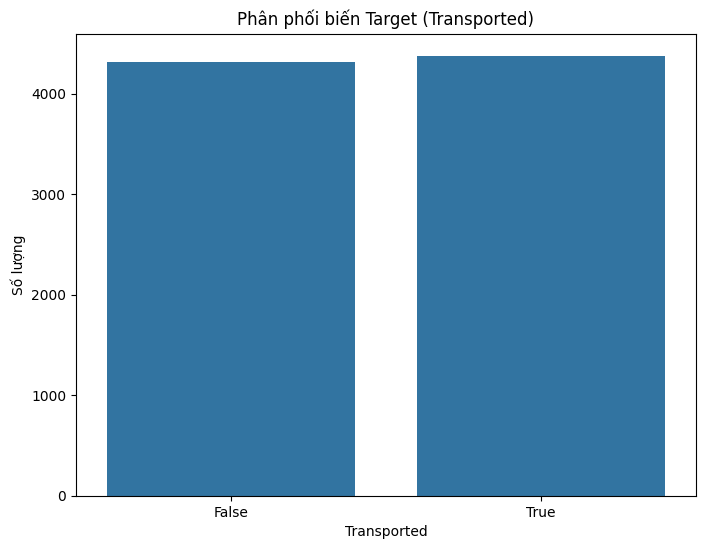

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.countplot(x='Transported', data = train)

plt.title('Phân phối biến Target (Transported)')
plt.xlabel('Transported')
plt.ylabel('Số lượng')
plt.show()

Tỉ lệ target đẹp.

In [11]:
import scipy.stats as stats
import numpy as np 

categorical = train.select_dtypes(include= 'object').columns

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))


cramers_results = {}
for i, feat1 in enumerate(categorical):
    for feat2 in categorical[i+1:]:
        try:
            v = cramers_v(train[feat1], train[feat2])
            cramers_results[(feat1, feat2)] = v
        except Exception as e:
            print(f"Không tính được cho {feat1} và {feat2}: {e}")


cramers_df = pd.DataFrame.from_dict(cramers_results, orient='index', columns=['Cramers_V'])
cramers_df = cramers_df.sort_values('Cramers_V', ascending = False)

print("\n Top 5 cặp biến categorical có Cramér's V cao nhất:")
print(cramers_df.head(5))

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14592\635722925.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14592\635722925.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14592\635722925.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))



 Top 5 cặp biến categorical có Cramér's V cao nhất:
                            Cramers_V
(HomePlanet, CabinDeck)      0.754450
(HomePlanet, Destination)    0.259493
(Destination, CabinDeck)     0.243530
(PassengerId, HomePlanet)         NaN
(PassengerId, Destination)        NaN


Cặp giá trị (HomePlanet, CabinDeck)      0.754450
mang tính liên hệ mạnh và khó có thể mang vào mô hình tuyến tính. Tạm thời chúng ta vẫn giữ lại để sau khi qua kiểm định vài bước nữa, chúng ta có thể quyết định có nên bỏ 1 trong 2 không.

Point-Biserial correlation (multi numerical features and categorical target)

In [12]:
from scipy.stats import pointbiserialr

# Lấy danh sách các cột numerical
numerical = train.select_dtypes(include=[np.number]).columns.tolist()

# Loại bỏ cột target nếu nó cũng là numerical
numerical = [col for col in numerical if col != 'Transported']

# Tính Point-Biserial correlation cho từng numerical feature với target
results = {}
for col in numerical:
    corr, pval = pointbiserialr(train['Transported'], train[col])
    results[col] = {'Correlation': corr, 'p-value': pval}

# Chuyển sang DataFrame để dễ nhìn
pb_df = pd.DataFrame(results).T.sort_values(by='Correlation', ascending=False)

print(pb_df)

              Correlation        p-value
FoodCourt        0.045583   2.122241e-05
ShoppingMall     0.009391   3.813140e-01
Age             -0.074233   4.216286e-12
VRDeck          -0.204874   4.969701e-83
Spa             -0.218545   1.701990e-94
RoomService     -0.241124  3.205394e-115


In [13]:
corr_matrix = train.select_dtypes(include=[np.number]).corr()
corr_pairs = (corr_matrix
              .abs()
              .unstack()
              .sort_values(ascending = False)
              .drop_duplicates())

print(corr_pairs)

Age           Age             1.000000
VRDeck        FoodCourt       0.224572
FoodCourt     Spa             0.221468
VRDeck        Spa             0.147658
FoodCourt     Age             0.127390
Spa           Age             0.120946
VRDeck        Age             0.099590
RoomService   Age             0.068629
              ShoppingMall    0.052337
Age           ShoppingMall    0.033148
RoomService   VRDeck          0.018624
FoodCourt     RoomService     0.015126
ShoppingMall  Spa             0.014542
              FoodCourt       0.013717
Spa           RoomService     0.009244
ShoppingMall  VRDeck          0.007849
dtype: float64


In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
numerical = train.select_dtypes(include=['int64', 'float64']).columns

X = train[numerical]
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by= 'VIF', ascending = False))

        feature       VIF
0           Age  1.369681
2     FoodCourt  1.191712
4           Spa  1.150123
5        VRDeck  1.142464
1   RoomService  1.112522
3  ShoppingMall  1.075743


Dựa vào giá trị VIF thì cả mô hình tuyến tính và phi tuyến đều dùng để train được. 
Trong trường hợp này nếu dùng tuyến tính ta sẽ drop feature Home_Planet

In [ ]:
# Ép Transported thành int (True -> 1, False -> 0)
train['Transported'] = train['Transported'].astype('int64')

numerical = train.select_dtypes(include=['int64', 'float64']).columns
categorical = train.select_dtypes(include= 'object').columns

print(numerical.tolist())
print(categorical.tolist())

['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
['PassengerId', 'HomePlanet', 'Destination', 'CabinDeck']
